# 🏦 Beyond the Credit Score — Loan Approval Classification

Restructured walkthrough of the team notebook
[prishababel/loan-approval-classification](https://www.kaggle.com/code/prishababel/loan-approval-classification)
(*Prisha Babel, Chad Rampersad, Dedeepya Pidaparthi, Brocatto200, Nishat, Samuel Oyekan* — Apache 2.0),
following its section plan. The reusable implementation lives in the `loan_approval`
package; this notebook tells the story — and implements the fairness analysis the
original scopes out in its section 12.

- **Dataset:** [Loan Approval Classification Dataset](https://www.kaggle.com/datasets/taweilo/loan-approval-classification-data) (Kaggle, taweilo) — 45,000 loan applications.
- **Target:** `loan_status` — 1 = approved, 0 = rejected.

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

sys.path.insert(0, str(Path.cwd().parent))  # make the loan_approval package importable

from loan_approval import config

# Validated chart palette (see README)
BLUE, ORANGE, MUTED = "#2a78d6", "#eb6834", "#898781"

print("All libraries imported successfully.")

All libraries imported successfully.


## 2. Load the dataset &nbsp;·&nbsp; 3. Initial exploration

In [2]:
raw = pd.read_csv(config.DATA_PATH)
print(f"Dataset loaded: {len(raw):,} rows, {raw.shape[1]} columns")
print(f"Missing values: {raw.isnull().sum().sum()}  |  Duplicate rows: {raw.duplicated().sum()}")
raw.head()

Dataset loaded: 45,000 rows, 14 columns
Missing values: 0  |  Duplicate rows: 0


,person_age,person_gender,person_education,person_income,person_emp_exp,person_home_ownership,loan_amnt,loan_intent,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,credit_score,previous_loan_defaults_on_file,loan_status
0,22.0,female,Master,71948.0,0,RENT,35000.0,PERSONAL,16.02,0.49,3.0,561,No,1
1,21.0,female,High School,12282.0,0,OWN,1000.0,EDUCATION,11.14,0.08,2.0,504,Yes,0
2,25.0,female,High School,12438.0,3,MORTGAGE,5500.0,MEDICAL,12.87,0.44,3.0,635,No,1
3,23.0,female,Bachelor,79753.0,0,RENT,35000.0,MEDICAL,15.23,0.44,2.0,675,No,1
4,24.0,male,Master,66135.0,1,RENT,35000.0,MEDICAL,14.27,0.53,4.0,586,No,1


In [3]:
raw.describe().T.round(2)

,count,mean,std,min,25%,50%,75%,max
person_age,45000.0,27.76,6.05,20.00,24.00,26.00,30.00,144.00
person_income,45000.0,80319.05,80422.50,8000.00,47204.00,67048.00,95789.25,7200766.00
person_emp_exp,45000.0,5.41,6.06,0.00,1.00,4.00,8.00,125.00
loan_amnt,45000.0,9583.16,6314.89,500.00,5000.00,8000.00,12237.25,35000.00
loan_int_rate,45000.0,11.01,2.98,5.42,8.59,11.01,12.99,20.00
loan_percent_income,45000.0,0.14,0.09,0.00,0.07,0.12,0.19,0.66
cb_person_cred_hist_length,45000.0,5.87,3.88,2.00,3.00,4.00,8.00,30.00
credit_score,45000.0,632.61,50.44,390.00,601.00,640.00,670.00,850.00
loan_status,45000.0,0.22,0.42,0.00,0.00,0.00,0.00,1.00


## 4. Data cleaning

Following the team notebook: ages above 110 and incomes above $1M are data
errors, and employment experience greater than or equal to age is impossible.

In [4]:
from loan_approval.data import load_dataset, split_features_target

df = load_dataset()
print(f"Rows removed: {len(raw) - len(df)}  |  Remaining: {len(df):,}")
print(f"Age now capped at {df.person_age.max():.0f}, income at ${df.person_income.max():,.0f}")

Rows removed: 28  |  Remaining: 44,972
Age now capped at 94, income at $994,605


## 5. Exploratory data analysis

Class balance, approval rates across applicant groups, and how the key
financial features separate approved from rejected loans.

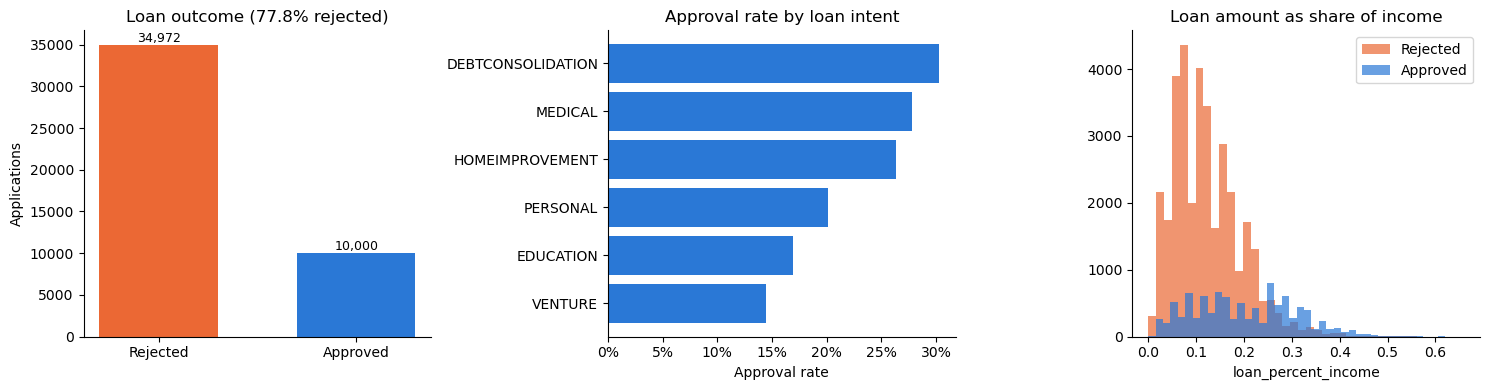

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

counts = df[config.TARGET].map(config.TARGET_LABELS).value_counts()
axes[0].bar(counts.index, counts.values, color=[ORANGE, BLUE], width=0.6)
for i, v in enumerate(counts.values):
    axes[0].text(i, v, f"{v:,}", ha="center", va="bottom", fontsize=9)
axes[0].set_title("Loan outcome (77.8% rejected)")
axes[0].set_ylabel("Applications")

rate = df.groupby("loan_intent")[config.TARGET].mean().sort_values()
axes[1].barh(rate.index, rate.values, color=BLUE)
axes[1].set_title("Approval rate by loan intent")
axes[1].set_xlabel("Approval rate")
axes[1].xaxis.set_major_formatter(lambda x, _: f"{x:.0%}")

for label, color in [("Rejected", ORANGE), ("Approved", BLUE)]:
    subset = df[df[config.TARGET].map(config.TARGET_LABELS) == label]
    axes[2].hist(subset["loan_percent_income"], bins=40, alpha=0.7, label=label, color=color)
axes[2].set_title("Loan amount as share of income")
axes[2].set_xlabel("loan_percent_income")
axes[2].legend()

for ax in axes:
    ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()

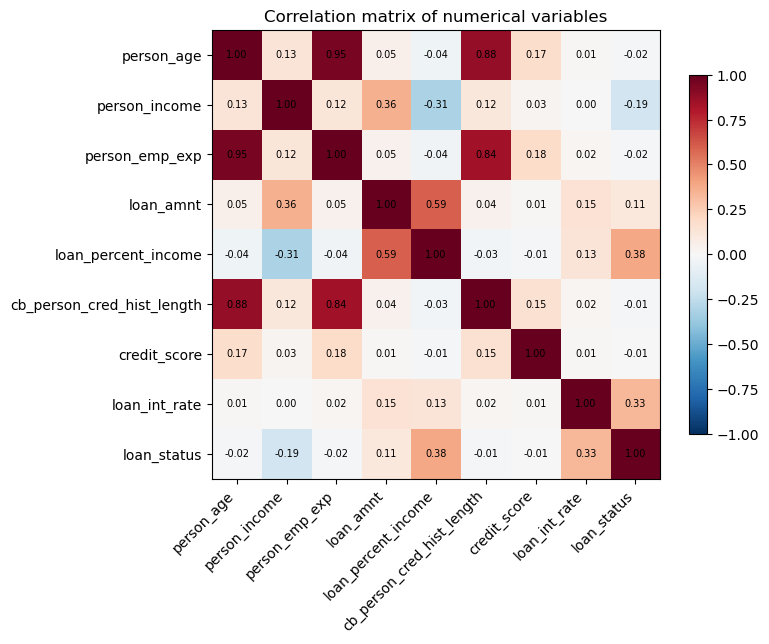

In [6]:
corr = df[config.NUMERIC_FEATURES + ["loan_int_rate", config.TARGET]].corr()

fig, ax = plt.subplots(figsize=(8, 6.5))
im = ax.imshow(corr, cmap="RdBu_r", vmin=-1, vmax=1)
ax.set_xticks(range(len(corr)), corr.columns, rotation=45, ha="right")
ax.set_yticks(range(len(corr)), corr.columns)
for i in range(len(corr)):
    for j in range(len(corr)):
        ax.text(j, i, f"{corr.iloc[i, j]:.2f}", ha="center", va="center", fontsize=7)
ax.set_title("Correlation matrix of numerical variables")
fig.colorbar(im, shrink=0.8)
plt.tight_layout()
plt.show()

**Key findings**

- Only ~22% of applications are approved, so accuracy alone is misleading;
  evaluation uses ROC-AUC, F1, precision, and recall.
- Loans that consume a large share of income are rejected far more often.
- `previous_loan_defaults_on_file` is decisive — no applicant with a prior
  default on file is approved anywhere in this dataset:

In [7]:
pd.crosstab(df["previous_loan_defaults_on_file"], df[config.TARGET].map(config.TARGET_LABELS))

loan_status,Approved,Rejected
previous_loan_defaults_on_file,,
No,10000,12132
Yes,0,22840


## 6–9. Encode, select features, split, scale

The team notebook one-hot encodes the categoricals (binary columns as single
0/1), **drops `loan_int_rate`** — the interest rate is set *after* the
approval decision, so using it would leak the answer — then does a stratified
80/20 split and standardizes numerics with statistics fit on the training
split only.

Here all of that lives in one scikit-learn `Pipeline`
(`ColumnTransformer` + model), so preprocessing is learned inside the
pipeline and can never leak from the test set, and the winning model
serializes to a single artifact.

In [8]:
from sklearn.model_selection import train_test_split

X, y = split_features_target(df)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=config.TEST_SIZE, stratify=y, random_state=config.RANDOM_STATE
)
print(f"Train: {len(X_train):,}  |  Test: {len(X_test):,}")
print(f"Features ({len(config.ALL_FEATURES)}): {config.ALL_FEATURES}")

Train: 35,977  |  Test: 8,995
Features (12): ['person_age', 'person_income', 'person_emp_exp', 'loan_amnt', 'loan_percent_income', 'cb_person_cred_hist_length', 'credit_score', 'person_gender', 'person_education', 'person_home_ownership', 'loan_intent', 'previous_loan_defaults_on_file']


## 11. Logistic Regression — baseline and tuned

`class_weight="balanced"` matters: with a 78/22 split an unweighted model
drifts toward predicting "rejected" every time. The tuned variant grid-searches
regularization strength and L1/L2 penalty with 5-fold stratified CV, scored on F1
(the team notebook's setup).

In [9]:
from loan_approval.evaluate import evaluate_model
from loan_approval.train import _pipeline, build_models, tune_logistic_regression

results = {}

baseline = _pipeline(build_models()["Logistic Regression (baseline)"])
baseline.fit(X_train, y_train)
results["Logistic Regression (baseline)"] = evaluate_model(baseline, X_test, y_test)

tuned, tuning = tune_logistic_regression(X_train, y_train)
results["Logistic Regression (tuned)"] = evaluate_model(tuned, X_test, y_test)
print(f"Best params: {tuning['best_params']}  |  CV F1: {tuning['cv_f1']}")

Best params: {'C': 100, 'penalty': 'l1', 'solver': 'liblinear'}  |  CV F1: 0.6913


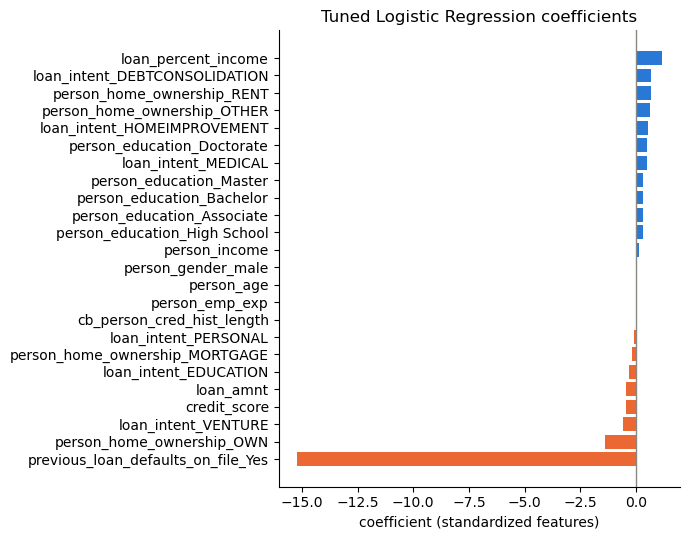

Most influential features:
previous_loan_defaults_on_file_Yes   -15.224
person_home_ownership_OWN             -1.367
loan_percent_income                    1.159
loan_intent_DEBTCONSOLIDATION          0.698
person_home_ownership_RENT             0.685
dtype: float64


In [10]:
coef = tuned.named_steps["model"].coef_[0]
names = tuned.named_steps["preprocess"].get_feature_names_out()
names = [n.split("__", 1)[1] for n in names]
importance = pd.Series(coef, index=names).sort_values()

fig, ax = plt.subplots(figsize=(7, 5.5))
ax.barh(importance.index, importance.values, color=[ORANGE if v < 0 else BLUE for v in importance.values])
ax.axvline(0, color=MUTED, linewidth=1)
ax.set_title("Tuned Logistic Regression coefficients")
ax.set_xlabel("coefficient (standardized features)")
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()

print("Most influential features:")
print(importance.reindex(importance.abs().sort_values(ascending=False).index).head(5).round(3))

## 12. Fairness analysis

The original notebook reserves this section (*"compare model performance by
gender and age … analyze any disparities across demographic groups"*) but
leaves it as a placeholder — implemented here. For each group:
predicted approval rate (demographic parity), true-positive rate (equal
opportunity), false-positive rate, and precision.

In [11]:
from loan_approval.fairness import fairness_report

report = fairness_report(tuned, X_test, y_test)
for dim, block in report.items():
    print(f"=== {dim} ===")
    print(pd.DataFrame(block["groups"]).T.to_string())
    print(f"demographic-parity gap: {block['demographic_parity_gap']:.1%}"
          f"  |  equal-opportunity gap: {block['equal_opportunity_gap']:.1%}\n")

=== person_gender ===
             n  actual_approval_rate  predicted_approval_rate  accuracy     tpr     fpr  precision
female  4026.0                0.2156                   0.3634    0.8184  0.9217  0.2099     0.5468
male    4969.0                0.2278                   0.3794    0.8038  0.9019  0.2252     0.5416
demographic-parity gap: 1.6%  |  equal-opportunity gap: 2.0%

=== age_band ===
            n  actual_approval_rate  predicted_approval_rate  accuracy     tpr     fpr  precision
<25    3171.0                0.2362                   0.3920    0.8146  0.9372  0.2234     0.5648
25-34  4753.0                0.2163                   0.3594    0.8111  0.8940  0.2118     0.5381
45+     181.0                0.2044                   0.3646    0.7624  0.8108  0.2500     0.4545
35-44   890.0                0.2090                   0.3719    0.8011  0.9140  0.2287     0.5136
demographic-parity gap: 3.3%  |  equal-opportunity gap: 12.6%



## 13. Validation & comparison

**13.1 With vs without demographic variables** — retrain the tuned model with
gender, age, and education removed. If the metrics barely move, decisions are
driven by financial features, not demographics.

In [12]:
from loan_approval.train import demographics_ablation

ablation = demographics_ablation(tuning["best_params"], X_train, y_train, X_test, y_test)
with_demo = {k: results["Logistic Regression (tuned)"][k] for k in ablation}
compare = pd.DataFrame({"With demographics": with_demo, "Without demographics": ablation})
compare["Difference"] = (compare["Without demographics"] - compare["With demographics"]).round(4)
compare

,With demographics,Without demographics,Difference
accuracy,0.8103,0.8100,-0.0003
precision,0.5439,0.5434,-0.0005
recall,0.9105,0.9100,-0.0005
f1,0.6810,0.6805,-0.0005
roc_auc,0.9310,0.9310,0.0000


**13.2 Stronger models** — Random Forest and Histogram Gradient Boosting
through the identical pipeline, for an apples-to-apples comparison.

In [13]:
for name in ["Random Forest", "Hist Gradient Boosting"]:
    pipe = _pipeline(build_models()[name])
    pipe.fit(X_train, y_train)
    results[name] = evaluate_model(pipe, X_test, y_test)

comparison = pd.DataFrame(results).T[["roc_auc", "accuracy", "precision", "recall", "f1"]]
comparison.sort_values("roc_auc", ascending=False).round(4)

,roc_auc,accuracy,precision,recall,f1
Hist Gradient Boosting,0.9583,0.9002,0.8264,0.6975,0.7565
Random Forest,0.9504,0.8938,0.8636,0.6205,0.7221
Logistic Regression (baseline),0.931,0.8107,0.5443,0.9115,0.6816
Logistic Regression (tuned),0.931,0.8103,0.5439,0.9105,0.681


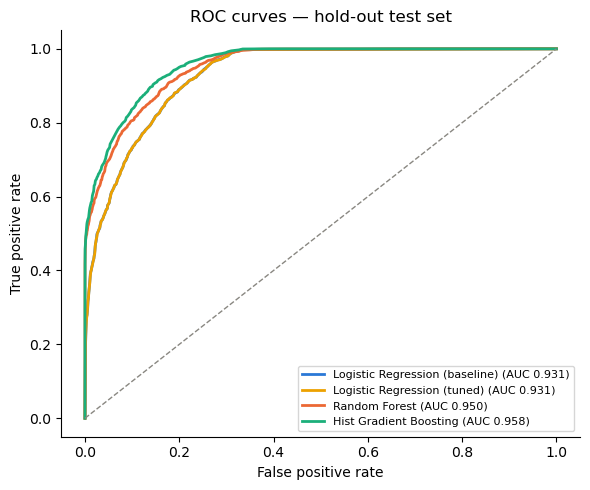

In [14]:
fig, ax = plt.subplots(figsize=(6, 5))
colors = {"Logistic Regression (baseline)": "#2a78d6", "Logistic Regression (tuned)": "#eda100",
          "Random Forest": "#eb6834", "Hist Gradient Boosting": "#1baf7a"}
for name, res in results.items():
    ax.plot(res["roc_curve"]["fpr"], res["roc_curve"]["tpr"],
            label=f"{name} (AUC {res['roc_auc']:.3f})", color=colors[name], linewidth=2)
ax.plot([0, 1], [0, 1], linestyle="--", color=MUTED, linewidth=1)
ax.set_xlabel("False positive rate")
ax.set_ylabel("True positive rate")
ax.set_title("ROC curves — hold-out test set")
ax.legend(loc="lower right", fontsize=8)
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()

**13.3 Cross-dataset consistency check** — the team notebook retrains the
same pipeline on the original
[Credit Risk Dataset](https://www.kaggle.com/datasets/laotse/credit-risk-dataset)
(the set this dataset was synthetically derived from; its `loan_status`
means *defaulted*, so this checks the pipeline, not an interchangeable model).
That file is not redistributed here — download `credit_risk_dataset.csv` from
Kaggle into `data/` and this cell will run the check.

In [15]:
if config.CREDIT_RISK_DATA_PATH.exists():
    from sklearn.compose import ColumnTransformer
    from sklearn.linear_model import LogisticRegression
    from sklearn.pipeline import Pipeline
    from sklearn.preprocessing import OneHotEncoder, StandardScaler

    df2 = pd.read_csv(config.CREDIT_RISK_DATA_PATH).dropna()
    y2 = df2["loan_status"]
    X2 = df2.drop(columns=["loan_status", "loan_int_rate", "loan_grade"])
    num2 = X2.select_dtypes("number").columns.tolist()
    cat2 = X2.select_dtypes("object").columns.tolist()

    X2_train, X2_test, y2_train, y2_test = train_test_split(
        X2, y2, test_size=0.2, stratify=y2, random_state=config.RANDOM_STATE
    )
    pipe2 = Pipeline([
        ("preprocess", ColumnTransformer([
            ("num", StandardScaler(), num2),
            ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False, drop="if_binary"), cat2),
        ])),
        ("model", LogisticRegression(max_iter=1000, class_weight="balanced",
                                     random_state=config.RANDOM_STATE)),
    ])
    pipe2.fit(X2_train, y2_train)
    m2 = evaluate_model(pipe2, X2_test, y2_test)
    print("Second dataset (Credit Risk) — same LR pipeline:")
    print({k: m2[k] for k in ["accuracy", "precision", "recall", "f1", "roc_auc"]})
else:
    print("data/credit_risk_dataset.csv not found — skipping (see note above).")

data/credit_risk_dataset.csv not found — skipping (see note above).


## 14. Conclusion

- The class-weighted Logistic Regression reproduces the team notebook's
  results (ROC-AUC ≈ 0.931, recall ≈ 0.91 on approved loans) and stays fully
  interpretable — approval hinges on prior defaults, loan-to-income ratio,
  home ownership, and loan intent.
- Histogram Gradient Boosting wins overall (ROC-AUC ≈ 0.958) and is what
  `python -m loan_approval.train` saves for the Streamlit app
  (`streamlit run streamlit_app.py`).
- Fairness: gender gaps are negligible; the age-band equal-opportunity gap
  (~11pp) is worth monitoring. Dropping demographics entirely changes
  metrics by ≤ 0.001, confirming decisions rest on financial features.